In [1]:
import pandas as pd

In [3]:
df = pd.read_csv("student_data.csv")

In [4]:
df.shape

(395, 33)

In [5]:
X = df.drop("G3", axis=1)
y = df["G3"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (395, 32)
Target: (395,)


In [6]:
X_encoded = pd.get_dummies(X, drop_first=True)

print("Original features:", X.shape[1])
print("Encoded features:", X_encoded.shape[1])

Original features: 32
Encoded features: 41


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (316, 41)
Testing data: (79, 41)


In [8]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


In [9]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[ 6.00160699 11.52847844  2.86643677  8.79663116  8.55310627 11.88964112
 19.09674195  7.17307901  7.4050707  12.31153657]


In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 1.6466656197147518
RMSE: 2.3783697847961376
R² Score: 0.7241341236974019


In [12]:
import matplotlib.pyplot as plt

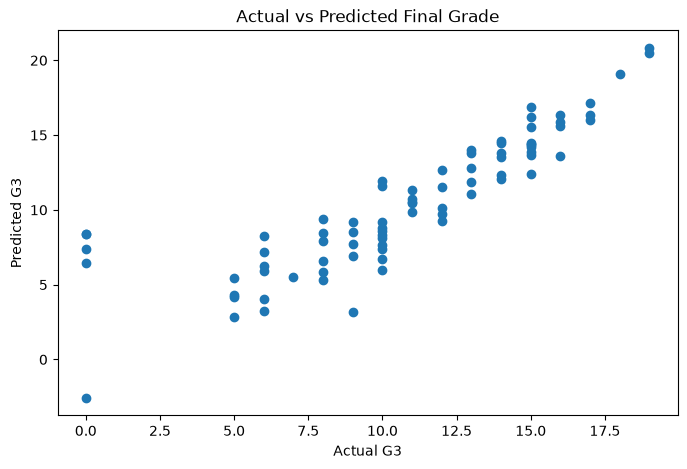

In [13]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual G3")
plt.ylabel("Predicted G3")
plt.title("Actual vs Predicted Final Grade")

plt.show()

In [14]:
feature_importance = pd.DataFrame({
    "Feature": X_encoded.columns,
    "Coefficient": model.coef_
})

feature_importance["Absolute_Coefficient"] = (
    feature_importance["Coefficient"].abs()
)

feature_importance = feature_importance.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

feature_importance.head(10)

,Feature,Coefficient,Absolute_Coefficient
14,G2,0.957772,0.957772
33,schoolsup_yes,0.785652,0.785652
28,reason_home,-0.611901,0.611901
36,activities_yes,-0.517500,0.517500
24,Fjob_health,0.481242,0.481242
20,Mjob_health,-0.463244,0.463244
40,romantic_yes,-0.390353,0.390353
38,higher_yes,0.375377,0.375377
16,sex_M,0.374410,0.374410
6,famrel,0.314962,0.314962


In [ ]:
# Model 2: Predict G3 without using previous grades G1 and G2
# Focus: study habits, absences, failures, family/support and other student factors

In [16]:
X_no_grades = df.drop(["G1", "G2", "G3"], axis=1)
y = df["G3"]

print("Features:", X_no_grades.shape)
print("Target:", y.shape)

Features: (395, 30)
Target: (395,)


In [17]:
X_no_grades_encoded = pd.get_dummies(X_no_grades, drop_first=True)

print("Original features:", X_no_grades.shape[1])
print("Encoded features:", X_no_grades_encoded.shape[1])

Original features: 30
Encoded features: 39


In [18]:
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X_no_grades_encoded,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X2_train.shape)
print("Testing data:", X2_test.shape)

Training data: (316, 39)
Testing data: (79, 39)


In [19]:
model2 = LinearRegression()

model2.fit(X2_train, y2_train)

print("Model 2 training completed!")

Model 2 training completed!


In [20]:
y2_pred = model2.predict(X2_test)

print(y2_pred[:10])

[ 1.88508025  7.45339224  8.30868805 11.55112413 10.20284528  9.43314825
 13.21126069 12.69040139 10.26673682 12.34152834]


In [21]:
mae2 = mean_absolute_error(y2_test, y2_pred)
rmse2 = np.sqrt(mean_squared_error(y2_test, y2_pred))
r2_2 = r2_score(y2_test, y2_pred)

print("Model 2 MAE:", mae2)
print("Model 2 RMSE:", rmse2)
print("Model 2 R² Score:", r2_2)

Model 2 MAE: 3.39526092580192
Model 2 RMSE: 4.1956808027213786
Model 2 R² Score: 0.14149247411195787


In [22]:
comparison = pd.DataFrame({
    "Model": ["Model 1 - With G1/G2", "Model 2 - Without G1/G2"],
    "MAE": [mae, mae2],
    "RMSE": [rmse, rmse2],
    "R2 Score": [r2, r2_2]
})

comparison

,Model,MAE,RMSE,R2 Score
0,Model 1 - With G1/G2,1.646666,2.378370,0.724134
1,Model 2 - Without G1/G2,3.395261,4.195681,0.141492


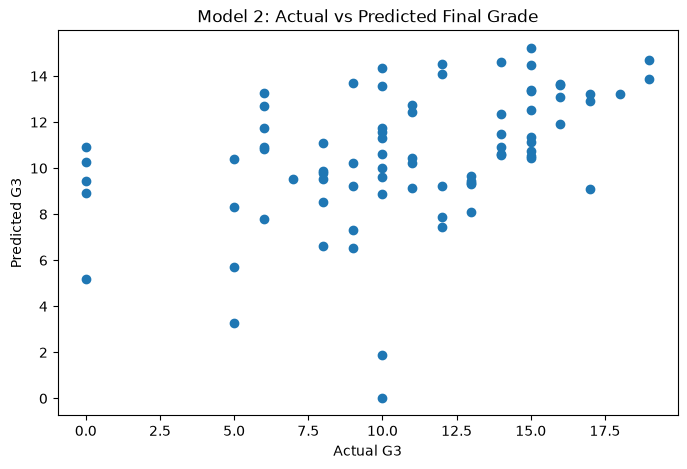

In [23]:
plt.figure(figsize=(8, 5))

plt.scatter(y2_test, y2_pred)

plt.xlabel("Actual G3")
plt.ylabel("Predicted G3")
plt.title("Model 2: Actual vs Predicted Final Grade")

plt.show()

In [24]:
model2_features = pd.DataFrame({
    "Feature": X_no_grades_encoded.columns,
    "Coefficient": model2.coef_
})

model2_features["Absolute_Coefficient"] = model2_features["Coefficient"].abs()

model2_features = model2_features.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

model2_features.head(10)

,Feature,Coefficient,Absolute_Coefficient
5,failures,-1.854106,1.854106
36,higher_yes,1.750880,1.750880
14,sex_M,1.495911,1.495911
32,famsup_yes,-1.256432,1.256432
18,Mjob_health,1.122322,1.122322
21,Mjob_teacher,-1.108470,1.108470
38,romantic_yes,-1.016167,1.016167
30,guardian_other,0.965251,0.965251
25,Fjob_teacher,0.939985,0.939985
31,schoolsup_yes,-0.915470,0.915470


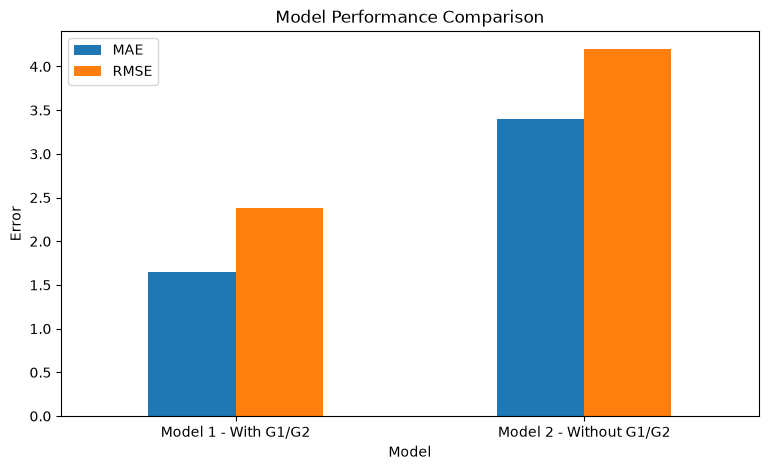

In [25]:
comparison.plot(
    x="Model",
    y=["MAE", "RMSE"],
    kind="bar",
    figsize=(9, 5)
)

plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Error")
plt.xticks(rotation=0)
plt.show()